In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

PROJECT_ROOT
DATA_ROOT = PROJECT_ROOT / "data" / "processed" / "bmpd_roi"
QUALITY_CSV_PATH = PROJECT_ROOT / "data" / "qc" / "roi_quality.csv"

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time
from sklearn.metrics import roc_curve, auc

from palmprint.models.siamese import SiameseNetwork
from palmprint.training.train import load_checkpoint

from palmprint.datasets.bmpd import (
    BMPDDatasetBuilder,
    BMPDDatasetConfig,
    QualityFilterConfig,
    SplitConfig,
)

from palmprint.sampling.pairs import generate_balanced_pairs
from palmprint.datasets.pair_dataset import PairDataset
from palmprint.utils.seed import set_seed
from palmprint.training.metrics import PalmprintMetrics

from torch.utils.data import DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseNetwork(
    embedding_dim=128,
    input_channels=1,
)

checkpoint = load_checkpoint(
    model,
    "../checkpoints/siamese_bmpd_roi_best.pt",
    device,
)

In [4]:
config = BMPDDatasetConfig(
    roi_dir=DATA_ROOT,
    split=SplitConfig(
        seed=42,
        train_ratio=0.7,
        val_ratio=0.1,
        test_ratio=0.2,
    ),
    quality_filter=QualityFilterConfig(
        apply_quality_filter=True,
        project_root=PROJECT_ROOT,
        quality_csv_path=QUALITY_CSV_PATH,
        verbose=True,
    ),
)

builder = BMPDDatasetBuilder(config)

splits = builder.build_splits()


=== ROI QUALITY FILTERING ===
Total images:     1612
Removed (bad):    89
Kept:             1523
Percent removed:  5.52%


In [5]:
test_pairs = generate_balanced_pairs(
    splits["test"],
    num_pairs=10000,
    seed=42,
)

print(f"Train pairs: {len(test_pairs)}")

Train pairs: 10000


In [6]:
test_dataset = PairDataset(
    test_pairs,
    image_size=224,
    grayscale=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

In [50]:
all_distances = []
all_labels = []

model.eval()

start_time = time.time()

with torch.no_grad():
    for img1, img2, labels in tqdm(test_loader, desc="Evaluating"):
        img1 = img1.to(device)
        img2 = img2.to(device)

        _emb1, _emb2, distances = model(img1, img2)

        all_distances.extend(distances.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end_time = time.time()

avg_verification_time_ms = ((end_time - start_time) / len(all_distances)) * 1000

print(f"Evaluated pairs: {len(all_distances)}")
print(f"Average verification time: {avg_verification_time_ms:.4f} ms/pair")

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 313/313 [13:03<00:00,  2.50s/it]

Evaluated pairs: 10000
Average verification time: 78.3966 ms/pair


In [51]:
def plot_roc(self):
    if self.y_scores is None:
        print("No scores provided for ROC curve.")
        return

    fpr, tpr, _ = roc_curve(self.y_true, self.y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
    plt.xlabel("False Positive Rate (FAR)")
    plt.ylabel("True Positive Rate (TAR)")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid()
    plt.show()

In [52]:
def plot_far_frr(self):
    if self.y_scores is None:
        print("No scores provided.")
        return

    fpr, tpr, thresholds = roc_curve(self.y_true, self.y_scores)
    fnr = 1 - tpr

    plt.figure()
    plt.plot(thresholds, fpr, label="FAR")
    plt.plot(thresholds, fnr, label="FRR")
    plt.xlabel("Threshold")
    plt.ylabel("Error Rate")
    plt.title("FAR vs FRR")
    plt.legend()
    plt.grid()
    plt.show()

In [53]:
def plot_score_distribution(self):
    if self.y_scores is None:
        print("No scores provided.")
        return

    genuine = self.y_scores[self.y_true == 1]
    imposter = self.y_scores[self.y_true == 0]

    plt.figure()
    plt.hist(genuine, bins=50, alpha=0.5, label="Genuine")
    plt.hist(imposter, bins=50, alpha=0.5, label="Imposter")
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.title("Score Distribution")
    plt.legend()
    plt.grid()
    plt.show()

==== Palmprint Evaluation Metrics ====
Accuracy : 0.7965
Precision: 0.8507
Recall   : 0.7192
F1-Score : 0.7795
FAR      : 0.1262
FRR      : 0.2808
EER      : 0.2106
TAR@FAR=0.01: 0.4352

Confusion Matrix:
[[4369  631]
 [1404 3596]]

Best threshold: -0.5228
Average verification time: 78.3966 ms/pair


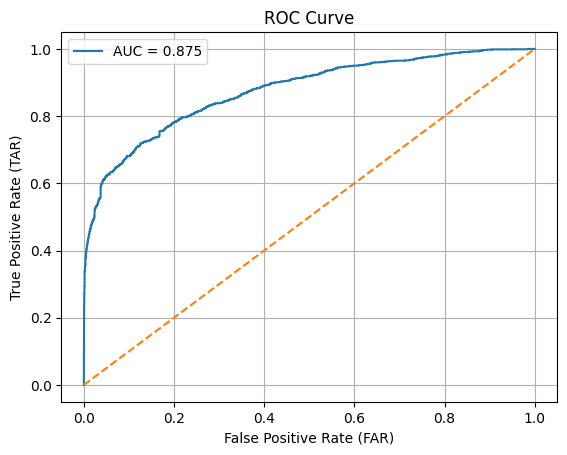

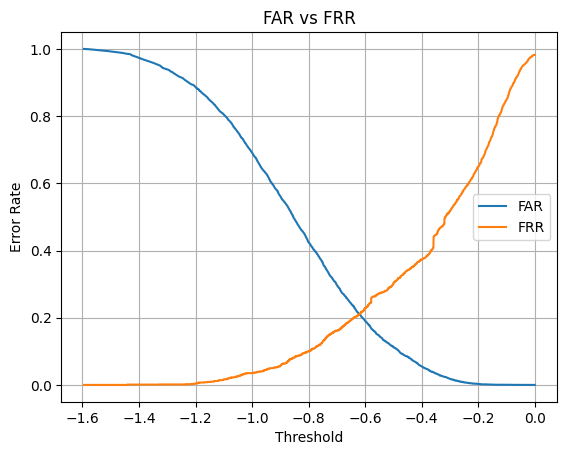

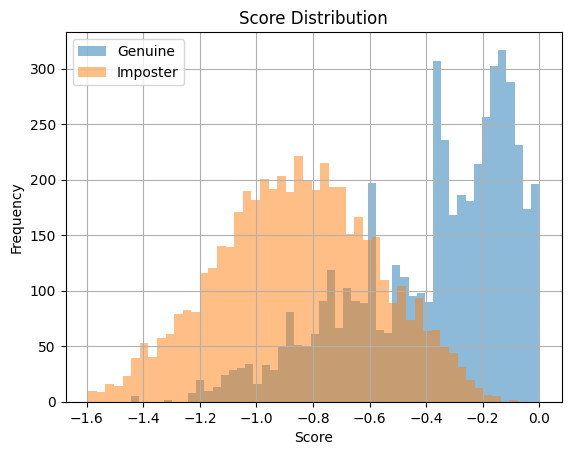

In [54]:
y_true = np.array(all_labels)
distances = np.array(all_distances)

# Lower distance means more similar.
y_scores = -distances

# Choose best threshold based on accuracy.
thresholds = np.unique(y_scores)

best_acc = 0
best_threshold = thresholds[0]

for threshold in thresholds:
    y_pred_candidate = (y_scores >= threshold).astype(int)
    acc = (y_pred_candidate == y_true).mean()

    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

y_pred = (y_scores >= best_threshold).astype(int)

metrics = PalmprintMetrics(
    y_true=y_true,
    y_pred=y_pred,
    y_scores=y_scores,
)

metrics.report()

print(f"\nBest threshold: {best_threshold:.4f}")
print(f"Average verification time: {avg_verification_time_ms:.4f} ms/pair")

plot_roc(metrics)
plot_far_frr(metrics)
plot_score_distribution(metrics)